# Building a movie recommender with Naïve Bayes

## 1. Preparing the data

In [40]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, classification_report

import matplotlib.pyplot as plt

In [41]:
data_path = "../../data/ml-1m/ratings.dat"
df = pd.read_csv(data_path, header=None, sep='::', engine='python')
df.columns = ['user_id', 'movie_id', 'rating', 'timestamp']

print(df)

         user_id  movie_id  rating  timestamp
0              1      1193       5  978300760
1              1       661       3  978302109
2              1       914       3  978301968
3              1      3408       4  978300275
4              1      2355       5  978824291
...          ...       ...     ...        ...
1000204     6040      1091       1  956716541
1000205     6040      1094       5  956704887
1000206     6040       562       5  956704746
1000207     6040      1096       4  956715648
1000208     6040      1097       4  956715569

[1000209 rows x 4 columns]


In [42]:
# How many unique users and movies are in this million-row dataset:
n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()

print(
  f"Number of users: {n_users}",
  f"\nNumber of movies: {n_movies}"
)

Number of users: 6040 
Number of movies: 3706


In [43]:
# Construct a 6,040 (no. of users) by 3,706 (no. of movies) matrix where each row contains movie ratings from a user, and each column represents a movie:
def load_user_rating_data(df, n_users, n_movies):
  data = np.zeros([n_users, n_movies], dtype=np.intc)
  movie_id_mapping = {}

  for user_id, movie_id, rating in zip(df['user_id'], df['movie_id'], df['rating']):
    user_id = int(user_id) - 1
    
    if movie_id not in movie_id_mapping:
      movie_id_mapping[movie_id] = len(movie_id_mapping)
    
    data[user_id, movie_id_mapping[movie_id]] = rating

  return data, movie_id_mapping

data, movie_id_mapping = load_user_rating_data(df, n_users, n_movies)

In [44]:
# Always recommended to analyze the data distribution in order to identify if there is a class imbalance issue in the dataset:
values, counts = np.unique(data, return_counts=True)

for value, count in zip(values, counts):
  print(f"Number of rating {value}: {count}")

Number of rating 0: 21384031
Number of rating 1: 56174
Number of rating 2: 107557
Number of rating 3: 261197
Number of rating 4: 348971
Number of rating 5: 226310


In [45]:
# Since most ratings are unknown, we take the movie with the most known ratings as our target movie for easier prediction validation:
print(df['movie_id'].value_counts())

movie_id
2858    3428
260     2991
1196    2990
1210    2883
480     2672
        ... 
3458       1
2226       1
1815       1
398        1
2909       1
Name: count, Length: 3706, dtype: int64


In [46]:
# The target movie is ID, and we will treat ratings of other movies as features. We only use rows with ratings available for the target movie so we can validate how good the prediction is:
target_movie_id = 2858
X_raw = np.delete(data, movie_id_mapping[target_movie_id], axis=1)
Y_raw = data[:, movie_id_mapping[target_movie_id]]
X = X_raw[Y_raw > 0]
Y = Y_raw[Y_raw > 0]

print(
  f"Shape of X: {X.shape}",
  f"\nShape of Y: {Y.shape}"
)

Shape of X: (3428, 3705) 
Shape of Y: (3428,)


In [47]:
# We can consider movies with ratings greater than 3 as being liked (being recommended):
recommend = 3
Y[Y <= recommend] = 0
Y[Y > recommend] = 1
n_pos = (Y == 1).sum()
n_neg = (Y == 0).sum()

print(f"{n_pos} positive samples and {n_neg} negative samples.")

2853 positive samples and 575 negative samples.


In [48]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# We check the training and testing sizes as follows:
print(len(Y_train), len(Y_test))

2742 686


## 2. Training a Naïve Bayes model

In [49]:
# Next, train a Naïve Bayes model on the training set. The values of the input features are from 0 to 5, as opposed to 0 or 1 in the toy example.
# ∴ we use the MultinomialNB module instead of the BernoulliNB module, as MultinomialNB can work with integer features as well as fractional counts.
clf = MultinomialNB(alpha=1.0, fit_prior=True)

clf.fit(X_train, Y_train)

# Use the trained model to make predictions on the testing set:
prediction_prob = clf.predict_proba(X_test)

print(prediction_prob[0:10])

[[7.50487439e-23 1.00000000e+00]
 [1.01806208e-01 8.98193792e-01]
 [3.57740570e-10 1.00000000e+00]
 [1.00000000e+00 2.94095407e-16]
 [1.00000000e+00 2.49760836e-25]
 [7.62630220e-01 2.37369780e-01]
 [3.47479627e-05 9.99965252e-01]
 [2.66075292e-11 1.00000000e+00]
 [5.88493563e-10 9.99999999e-01]
 [9.71326867e-09 9.99999990e-01]]


In [50]:
# We get the predicted class for the test set as follows:
prediction = clf.predict(X_test)

print(prediction[:10])

[1 1 1 0 0 0 1 1 1 1]


In [51]:
# Finally, evaluate the model's performance with classification accuracy, which is the proportion of correct predictions:
accuracy = clf.score(X_test, Y_test)

print(f"The accuracy is: {accuracy * 100:.1f}%")

The accuracy is: 71.6%


## 3. Evaluating classification performance

Beyond accuracy, other metrics used to gain more insight and avoid class imbalance effects are:
  
  - Confusion matrix
  - Precision
  - Recall
  - F1 score
  - Area under the curve

### Confusion matrix:

In [52]:
conf_matrix = confusion_matrix(Y_test, prediction, labels=[0, 1])

print(conf_matrix)

[[ 60  47]
 [148 431]]


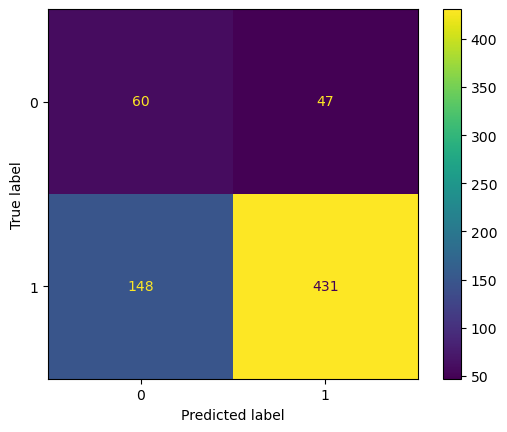

In [53]:
conf_matrix_display = ConfusionMatrixDisplay(
  confusion_matrix=conf_matrix,
  display_labels=clf.classes_
)

conf_matrix_display.plot()
plt.show()

### Precision score:

In [54]:
p_score = precision_score(Y_test, prediction, pos_label=1)

print(f"Precision score: {p_score:.2f}")

Precision score: 0.90


### Recall score:

In [55]:
r_score = recall_score(Y_test, prediction, pos_label=1)

print(f"Recall score: {r_score:.2f}")

Recall score: 0.74


___

#### Precision Recall visualization:

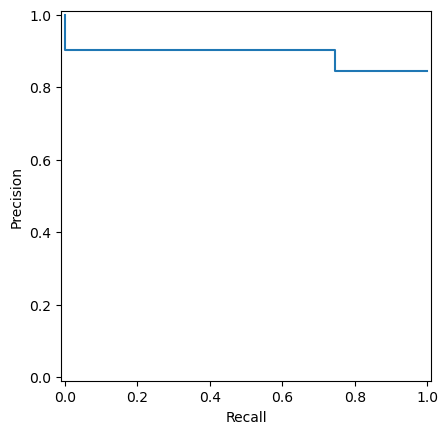

In [56]:
precision, recall, _ = precision_recall_curve(Y_test, prediction)
precision_recall_display = PrecisionRecallDisplay(
  precision=precision,
  recall=recall
)

precision_recall_display.plot()
plt.show()

___

### F1 score:

In [57]:
f_score = f1_score(Y_test, prediction, pos_label=1)

print(f"F1 score: {f_score:.2f}")

F1 score: 0.82


In [58]:
# The negative (dislike) class can also be viewed as positive, depending on the context. E.g. assign the 0 class as pos_label:
print(
  f"F1 score: {f1_score(Y_test, prediction, pos_label=0):.2f}"
)

F1 score: 0.38


In [59]:
# A quicker way to obtain the precision, recall and f1 score for each class is to call the classification_report function:
report = classification_report(Y_test, prediction)

print(report)

              precision    recall  f1-score   support

           0       0.29      0.56      0.38       107
           1       0.90      0.74      0.82       579

    accuracy                           0.72       686
   macro avg       0.60      0.65      0.60       686
weighted avg       0.81      0.72      0.75       686



In [61]:
# Let's code and exhibit the ROC curve (under thresholds of 0.0, 0.1, 0.2, ..., 1.0) of our model:
pos_prob = prediction_prob[:, 1]
thresholds = np.arange(0.0, 1.1, 0.05)
true_pos, false_pos = [0] * len(thresholds), [0] * len(thresholds)

for pred, y in zip(pos_prob, Y_test):
  for i, threshold in enumerate(thresholds):
    if pred >= threshold:
      # if truth and prediction are both 1
      if y == 1:
        true_pos[i] += 1
      # if truth is 0 while prediction is 1
      else:
        false_pos[i] += 1
    else:
      break

# Calculate the true and false positive rates for all threshold settings (there are 516.0 positive testing samples and 1191 negative ones):
n_pos_test = (Y_test == 1).sum()
n_neg_test = (Y_test == 0).sum()
true_pos_rate = [tp / n_pos_test for tp in true_pos]
false_pos_rate = [fp / n_neg_test for fp in false_pos]

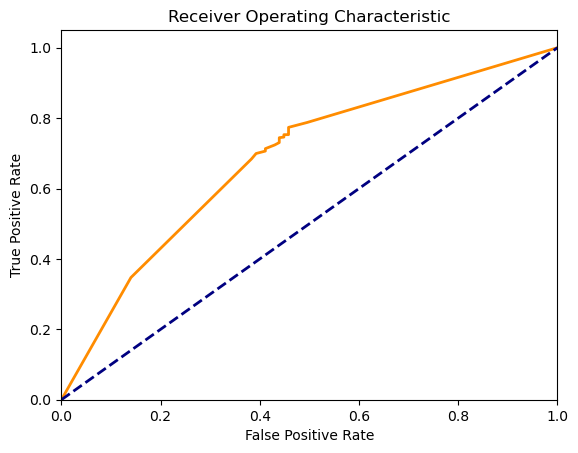

In [75]:
# Plot the ROC curve with matplotlib:
plt.figure()
lw = 2
plt.plot(false_pos_rate, true_pos_rate, color='darkorange', lw=lw)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
# plt.legend(loc='lower right')
plt.show()